In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"../data/raw/weatherHistory.csv")

In [3]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [4]:
df.shape

(96453, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 16.3 MB


In [6]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [7]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [8]:
def simplify_weather(summary):
    summary = summary.lower()

    if 'rain' in summary or 'drizzle' in summary:
        return 'Rainy'
    elif 'foggy' in summary:
        return 'Foggy'
    elif 'cloudy' in summary or 'overcast' in summary:
        return 'Cloudy'
    elif 'clear' in summary:
        return 'Clear'
    elif 'windy' in summary or 'breezy' in summary:
        return 'Windy'
    else:
        return 'Other'


df['Daily Summary'] = df['Daily Summary'].apply(simplify_weather)

In [9]:
print(df['Daily Summary'].value_counts().tolist())

[76191, 19037, 913, 240, 72]


In [10]:
print(df['Daily Summary'].unique())

<ArrowStringArray>
['Cloudy', 'Foggy', 'Clear', 'Rainy', 'Windy']
Length: 5, dtype: str


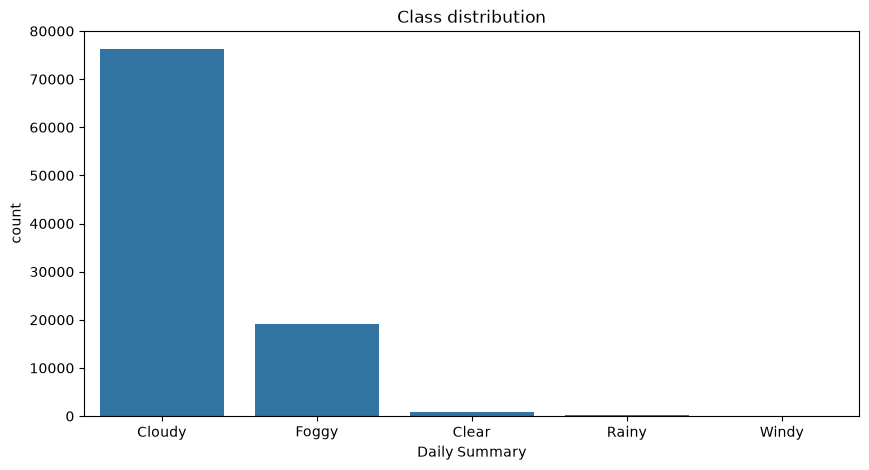

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['Daily Summary'])
plt.title("Class distribution")
plt.show()

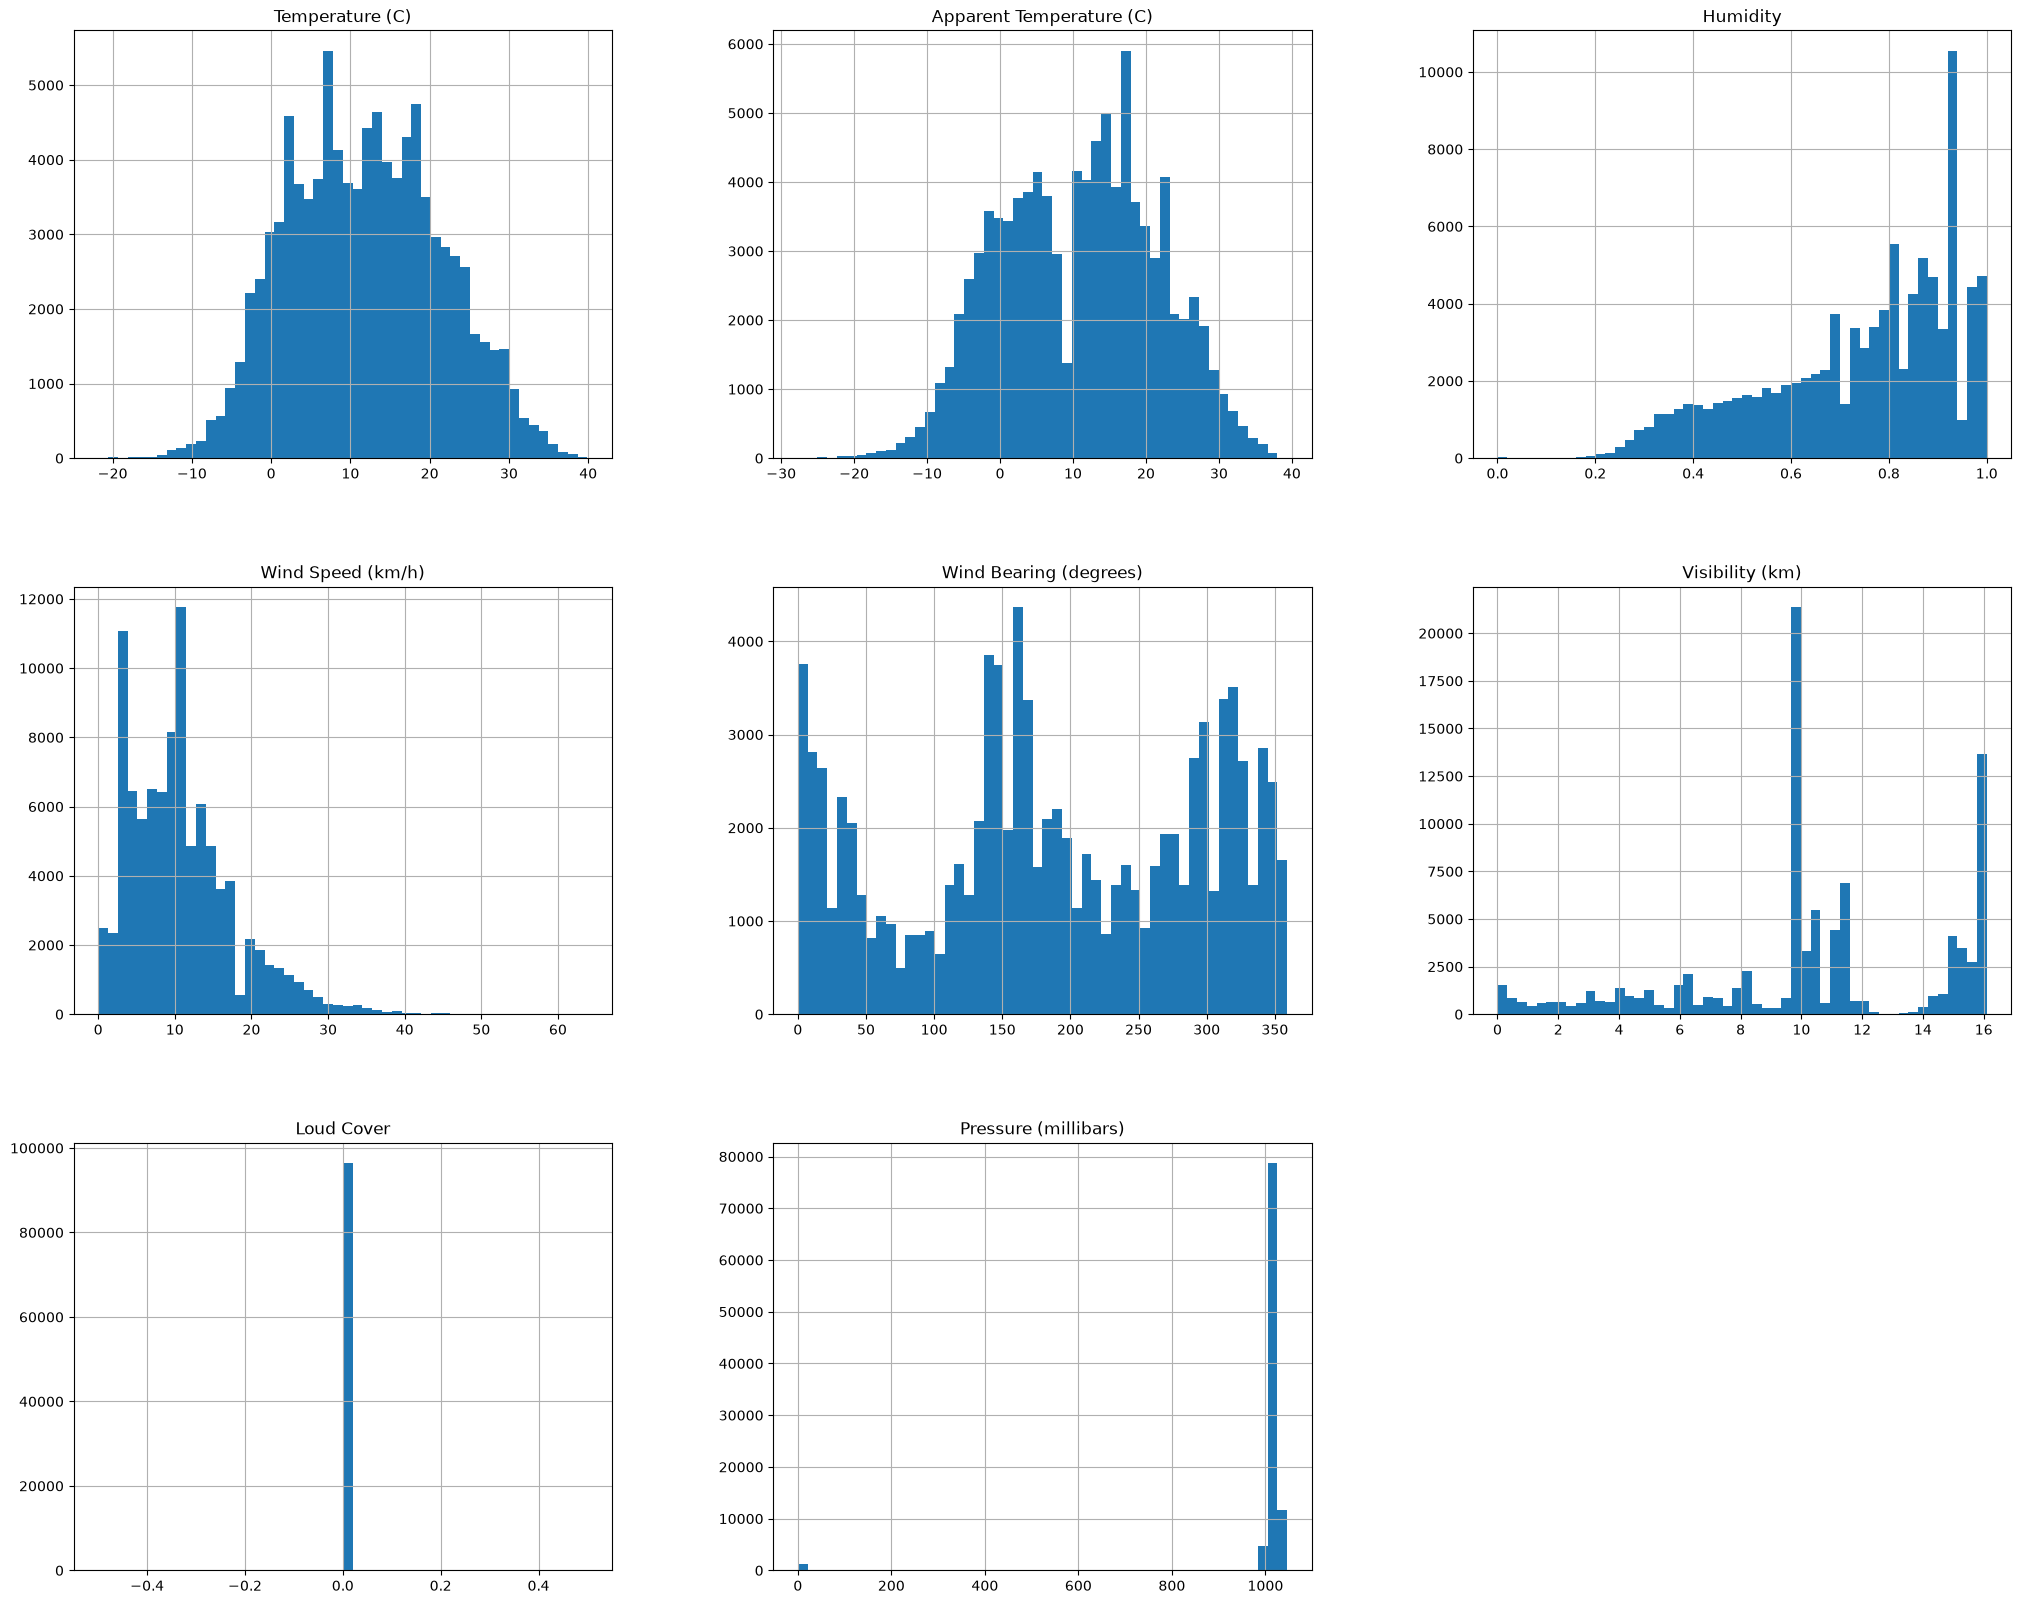

In [12]:
df.hist(bins=50, figsize=(25,20))
plt.show()

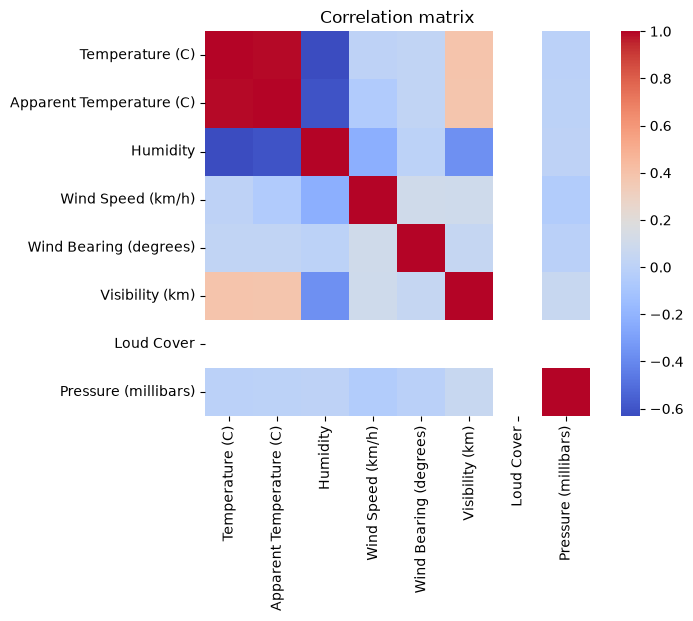

In [13]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True)
plt.title("Correlation matrix")
plt.show()

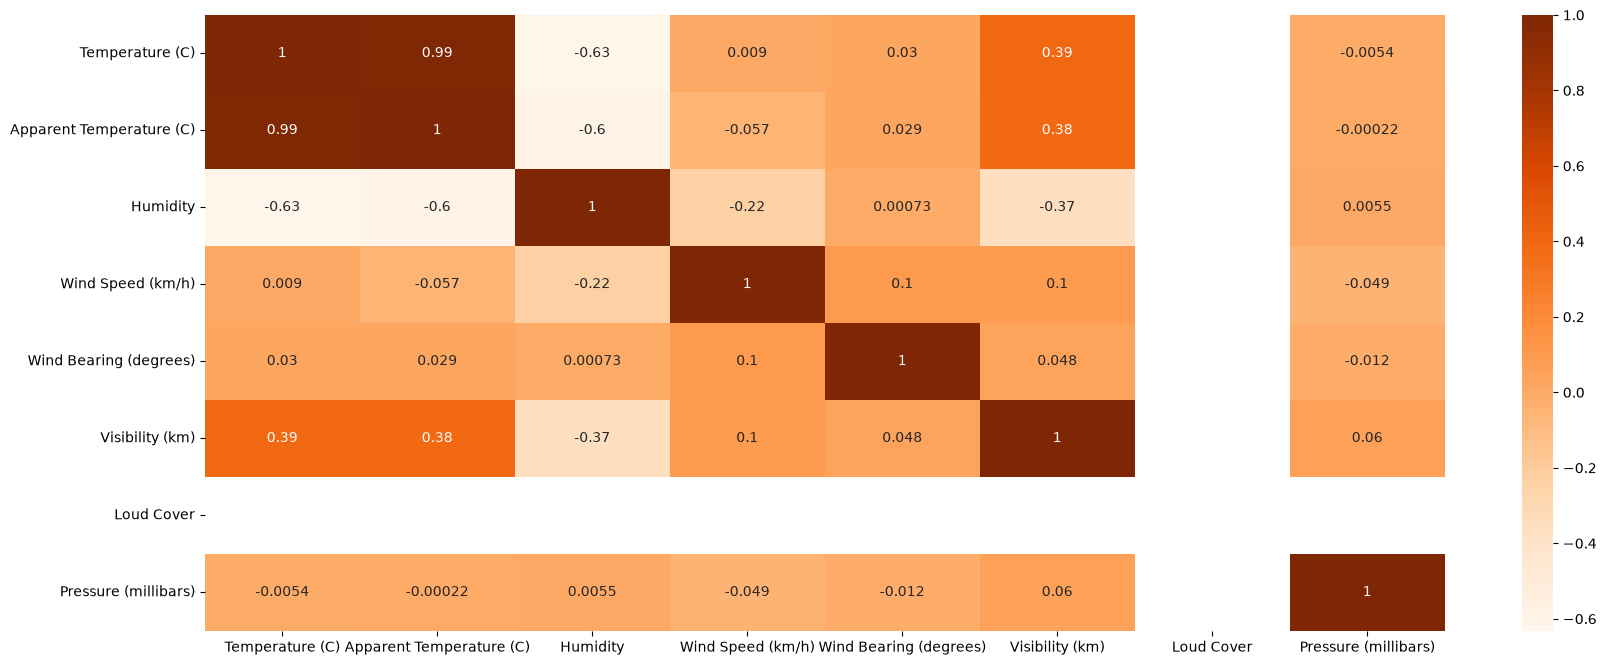

In [14]:
plt.figure(figsize=(20, 8))
hmp = df.corr(numeric_only=True)
sns.heatmap(hmp, cmap='Oranges', annot=True)
plt.show()

In [15]:
column_names = df.columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

C:\Users\Thanuja\AppData\Local\Temp\ipykernel_3860\1093590612.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


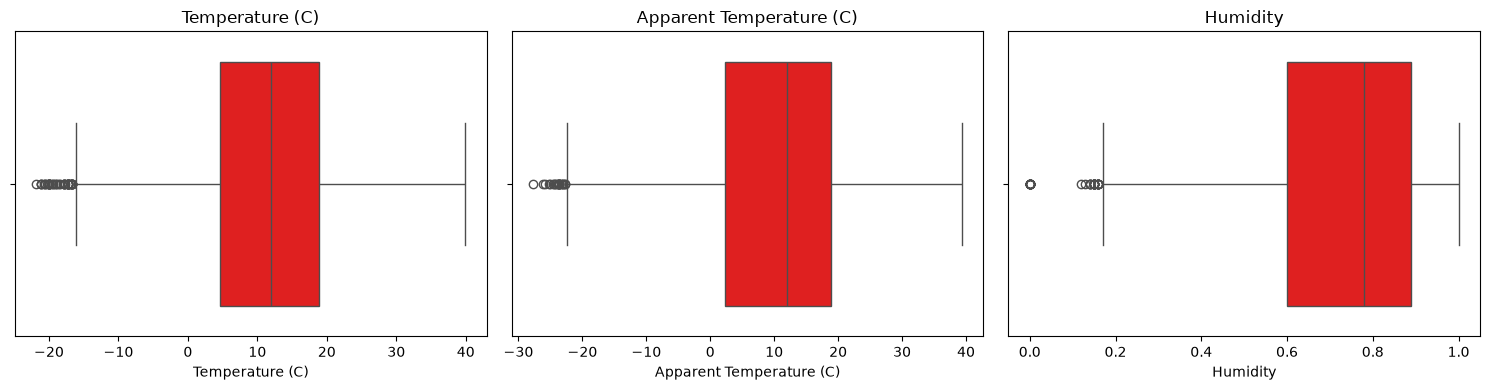

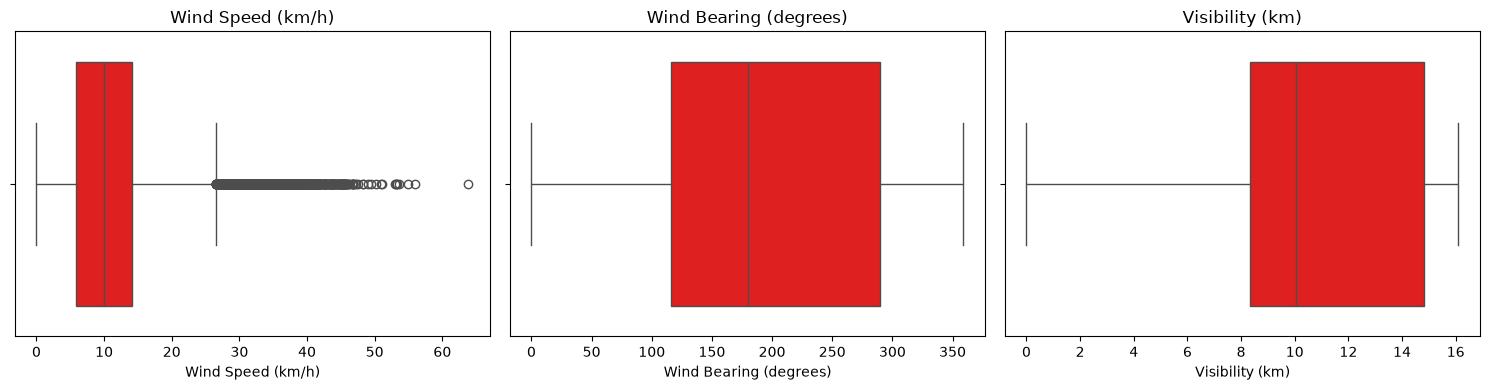

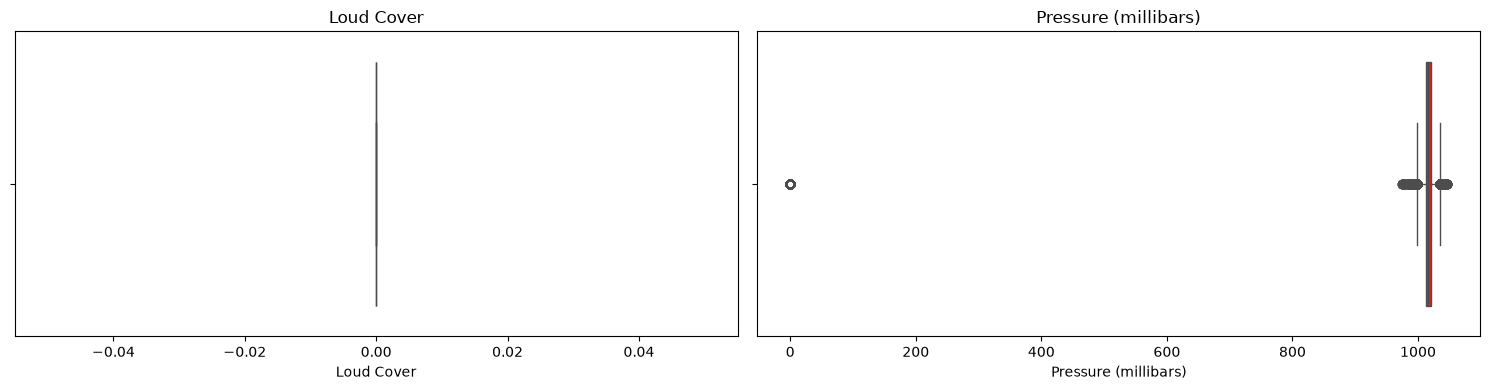

In [16]:
box_plt_cols = numerical_cols[0:]

n_cols = 3

for start in range(0, len(box_plt_cols), n_cols):
    cols = box_plt_cols[start:start + n_cols]

    fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, cols):
        sns.boxplot(x=df[col], color='red', ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

    plt.close(fig)

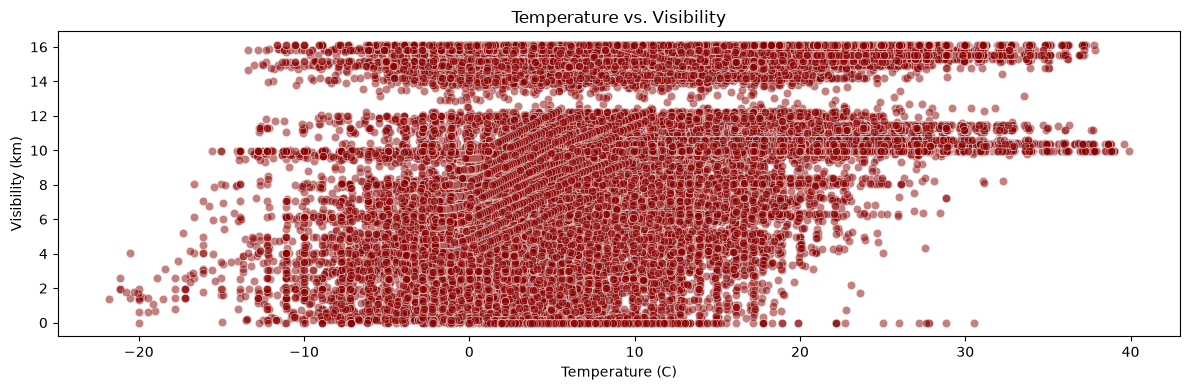

In [17]:
plt.figure(figsize=(12, 4))

plt.plot(1, 2, 2)
sns.scatterplot(data=df, x='Temperature (C)', y='Visibility (km)', alpha=0.5, color='darkred')
plt.title("Temperature vs. Visibility")

plt.tight_layout()
plt.show()

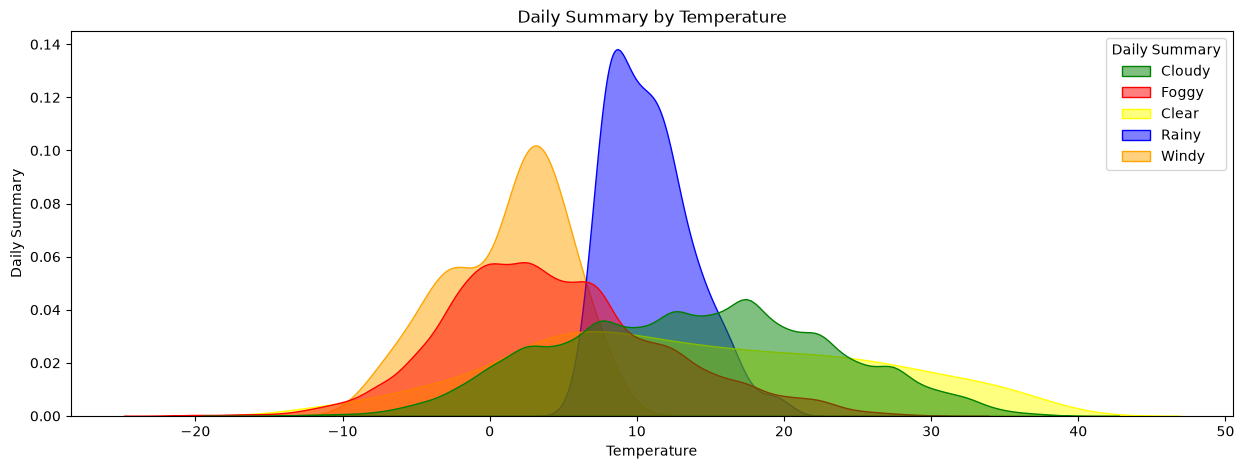

In [18]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=df, x='Temperature (C)', hue='Daily Summary', fill=True, common_norm=False, palette={'Cloudy': 'green', 'Foggy': 'red', 'Clear': 'yellow', 'Rainy': 'blue', 'Windy': 'orange'}, alpha=0.5)
plt.title("Daily Summary by Temperature")
plt.xlabel("Temperature")
plt.ylabel("Daily Summary")
plt.show()

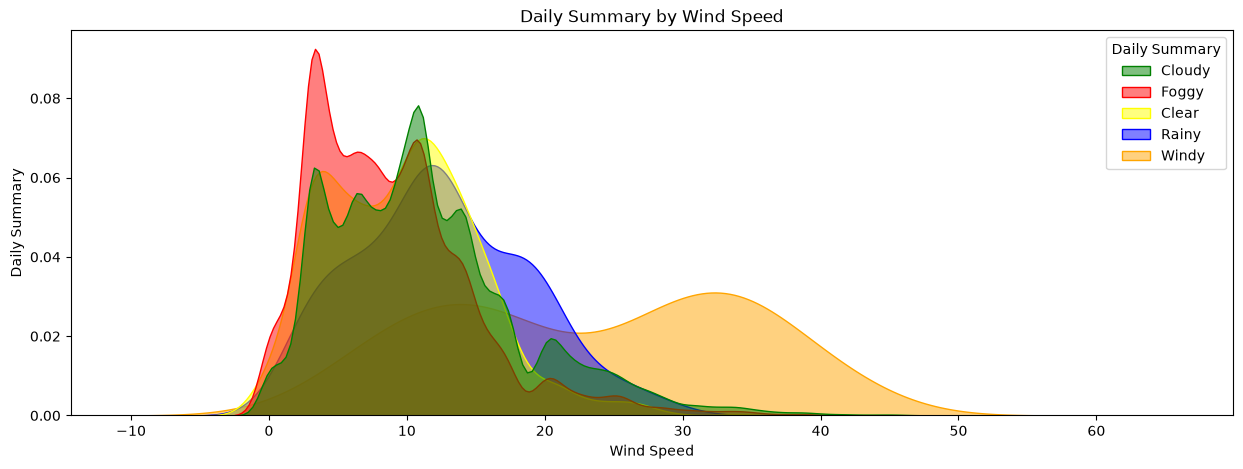

In [19]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=df, x='Wind Speed (km/h)', hue='Daily Summary', fill=True, common_norm=False, palette={'Cloudy': 'green', 'Foggy': 'red', 'Clear': 'yellow', 'Rainy': 'blue', 'Windy': 'orange'}, alpha=0.5)
plt.title("Daily Summary by Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("Daily Summary")
plt.show()

In [20]:
df['Month'] = pd.to_datetime(
    df['Formatted Date'],
    utc=True
).dt.month_name()

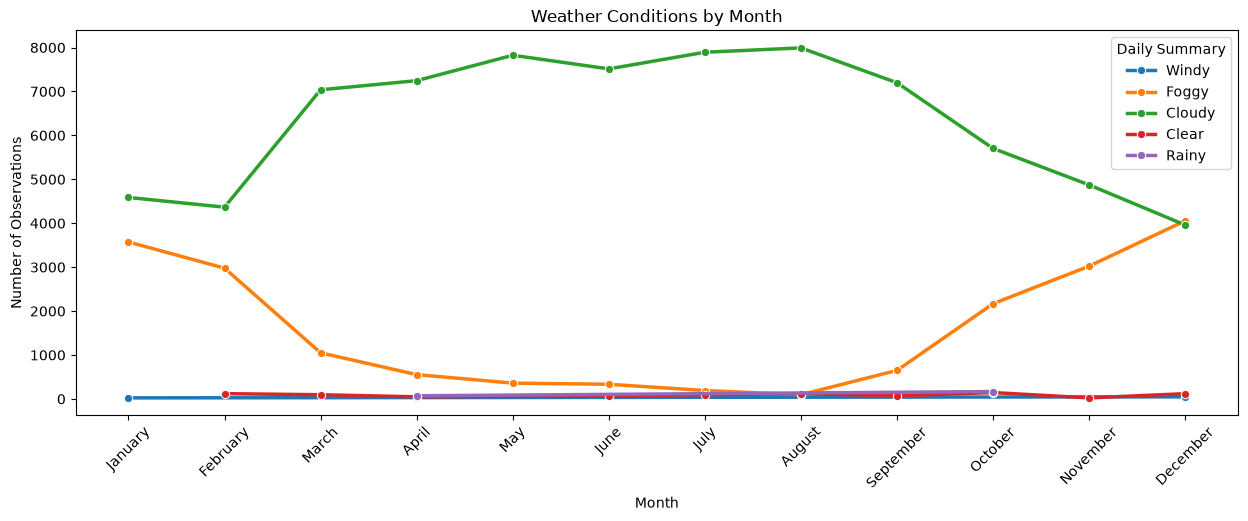

In [21]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_data = (df.groupby(['Month', 'Daily Summary']).size().reset_index(name='Count'))

monthly_data['Month'] = pd.Categorical(monthly_data['Month'],categories=month_order,ordered=True)

monthly_data = monthly_data.sort_values('Month')

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_data,
    x='Month',
    y='Count',
    hue='Daily Summary',
    marker='o',
    linewidth=2.5
)

plt.title("Weather Conditions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.show()

In [22]:
df['Date'] = pd.to_datetime(
    df['Formatted Date'],
    utc=True
).dt.day

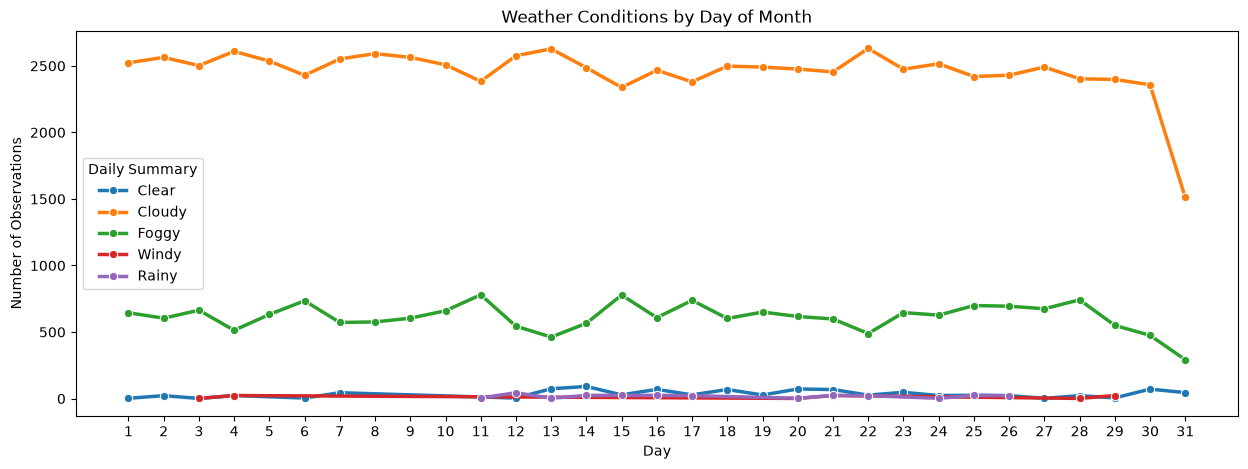

In [23]:
date_order = list(range(1, 32))

daily_data = (
    df.groupby(['Date', 'Daily Summary'])
      .size()
      .reset_index(name='Count')
)

daily_data['Date'] = pd.Categorical(
    daily_data['Date'],
    categories=date_order,
    ordered=True
)

daily_data = daily_data.sort_values('Date')

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=daily_data,
    x='Date',
    y='Count',
    hue='Daily Summary',
    marker='o',
    linewidth=2.5
)

plt.title("Weather Conditions by Day of Month")
plt.xlabel("Day")
plt.ylabel("Number of Observations")
plt.xticks(range(1, 32))
plt.show()

In [24]:
df['Hour'] = pd.to_datetime(
    df['Formatted Date'],
    utc=True
).dt.hour

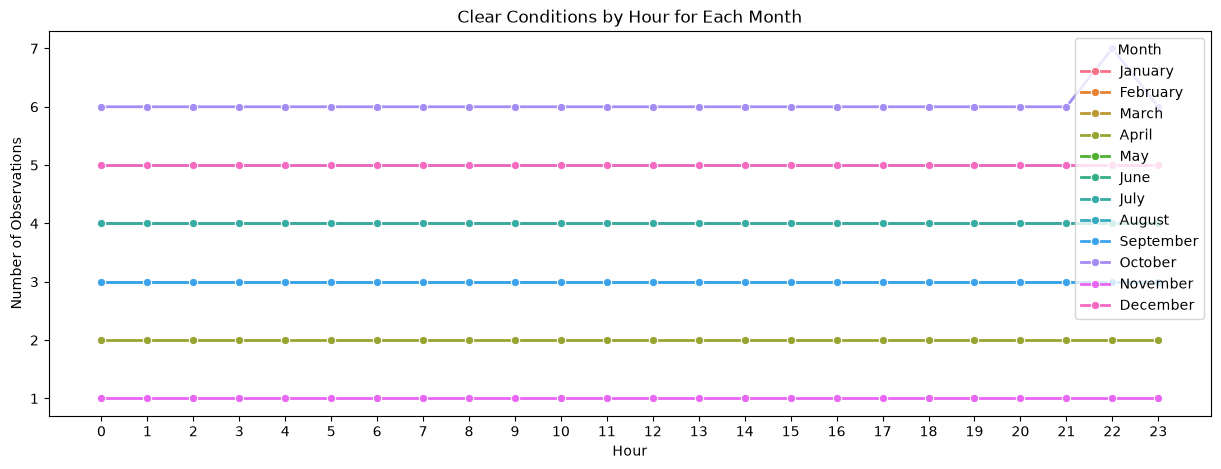

In [25]:
monthly_hour = (
    df[df['Daily Summary'] == 'Clear']
    .groupby(['Month', 'Hour'])
    .size()
    .reset_index(name='Count')
)

monthly_hour['Month'] = pd.Categorical(
    monthly_hour['Month'],
    categories=month_order,
    ordered=True
)

monthly_hour = monthly_hour.sort_values(['Month', 'Hour'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_hour,
    x='Hour',
    y='Count',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Clear Conditions by Hour for Each Month")
plt.xlabel("Hour")
plt.ylabel("Number of Observations")
plt.xticks(range(24))
plt.show()

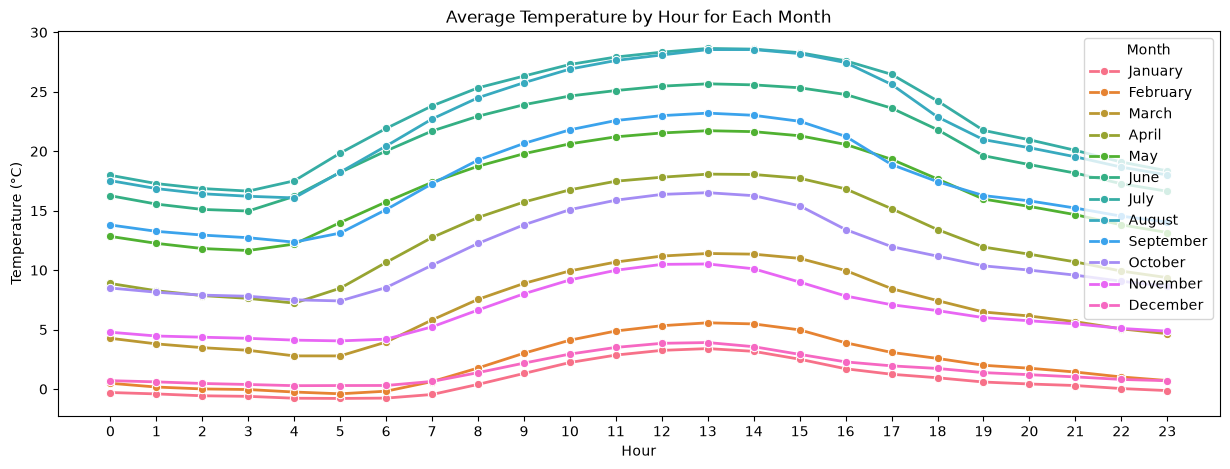

In [26]:
monthly_hour = (
    df.groupby(['Month', 'Hour'])['Temperature (C)']
      .mean()
      .reset_index(name='Temperature')
)

monthly_hour['Month'] = pd.Categorical(
    monthly_hour['Month'],
    categories=month_order,
    ordered=True
)

monthly_hour = monthly_hour.sort_values(['Month', 'Hour'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_hour,
    x='Hour',
    y='Temperature',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Average Temperature by Hour for Each Month")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.xticks(range(24))
plt.show()

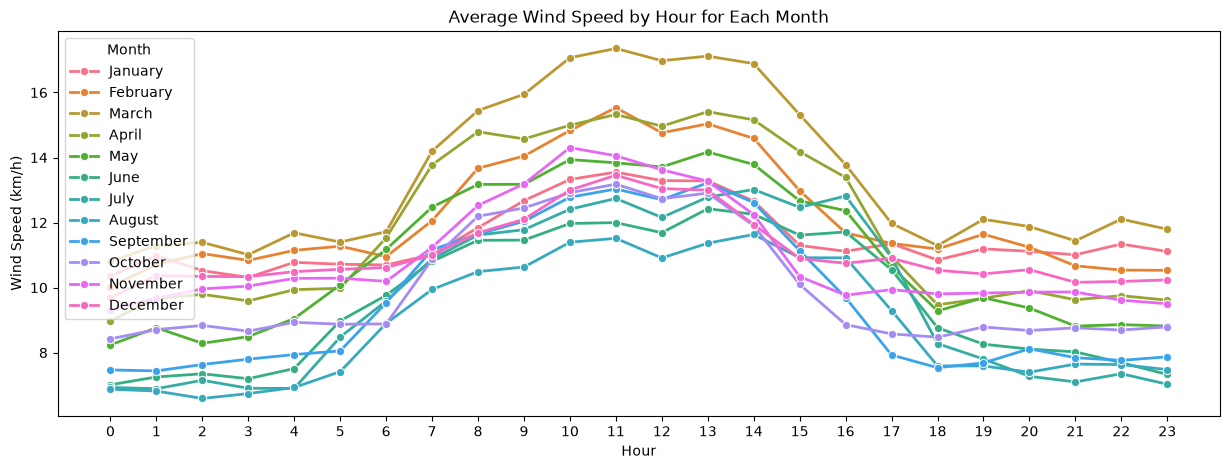

In [27]:
monthly_hour = (
    df.groupby(['Month', 'Hour'])['Wind Speed (km/h)']
      .mean()
      .reset_index(name='Wind Speed')
)

monthly_hour['Month'] = pd.Categorical(
    monthly_hour['Month'],
    categories=month_order,
    ordered=True
)

monthly_hour = monthly_hour.sort_values(['Month', 'Hour'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_hour,
    x='Hour',
    y='Wind Speed',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Average Wind Speed by Hour for Each Month")
plt.xlabel("Hour")
plt.ylabel("Wind Speed (km/h)")
plt.xticks(range(24))
plt.show()

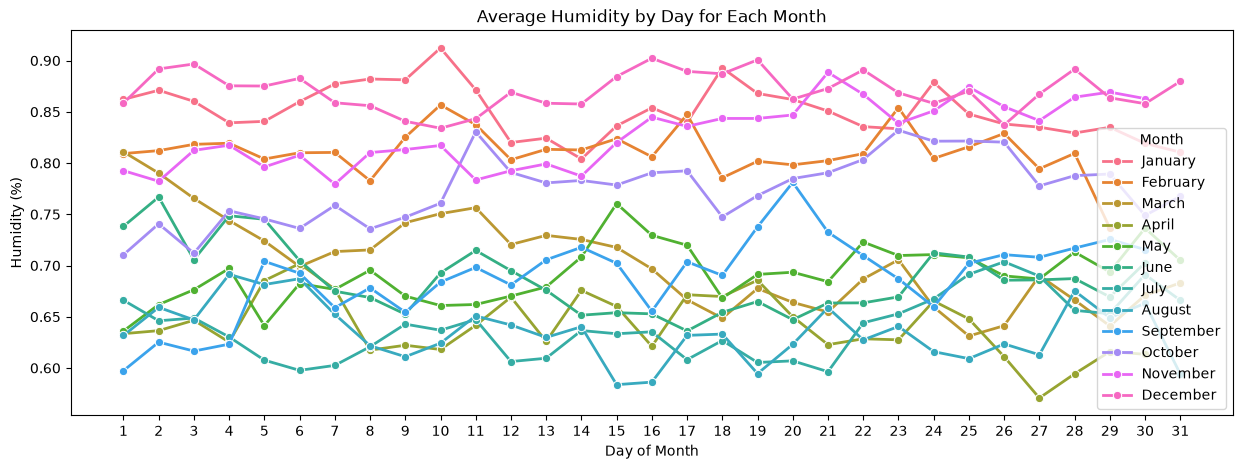

In [28]:
monthly_day = (
    df.groupby(['Month', 'Date'])['Humidity']
      .mean()
      .reset_index(name='Humidity')
)

monthly_day['Month'] = pd.Categorical(
    monthly_day['Month'],
    categories=month_order,
    ordered=True
)

monthly_day = monthly_day.sort_values(['Month', 'Date'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_day,
    x='Date',
    y='Humidity',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Average Humidity by Day for Each Month")
plt.xlabel("Day of Month")
plt.ylabel("Humidity (%)")
plt.xticks(range(1, 32))
plt.show()

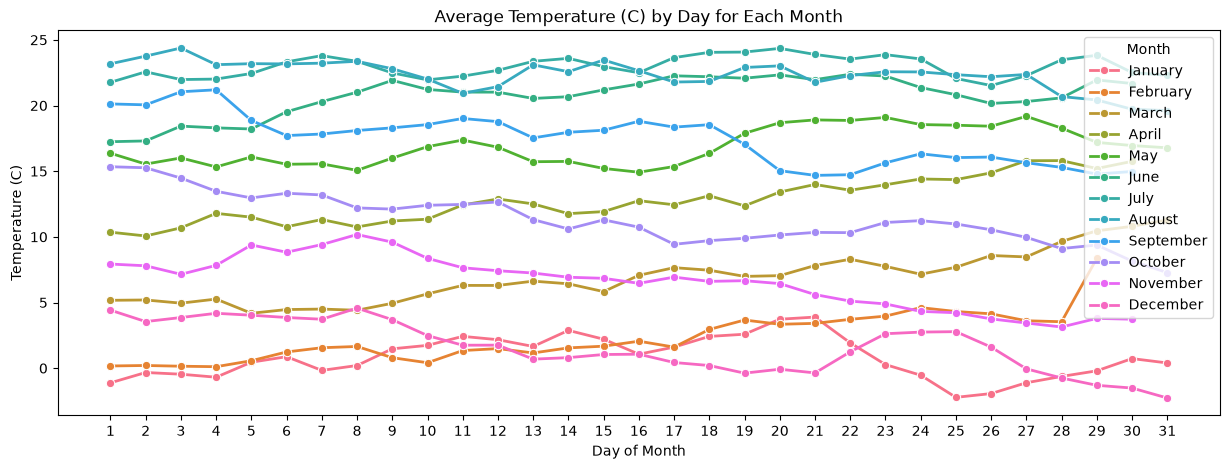

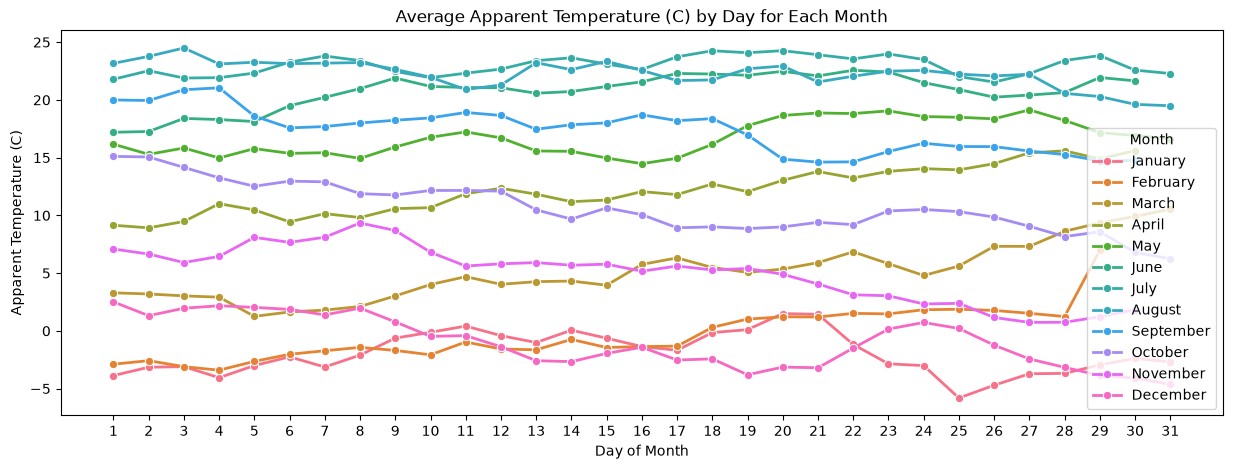

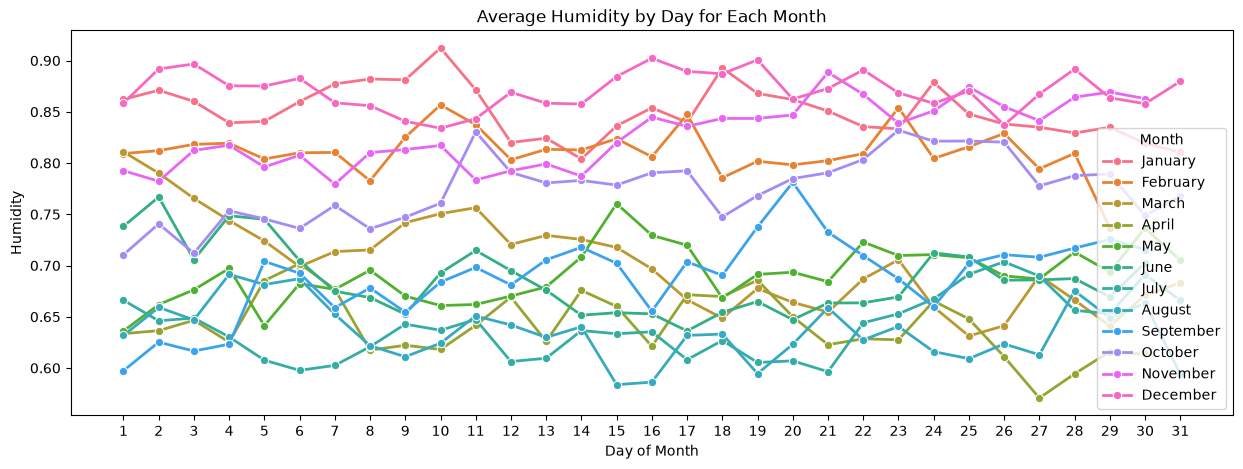

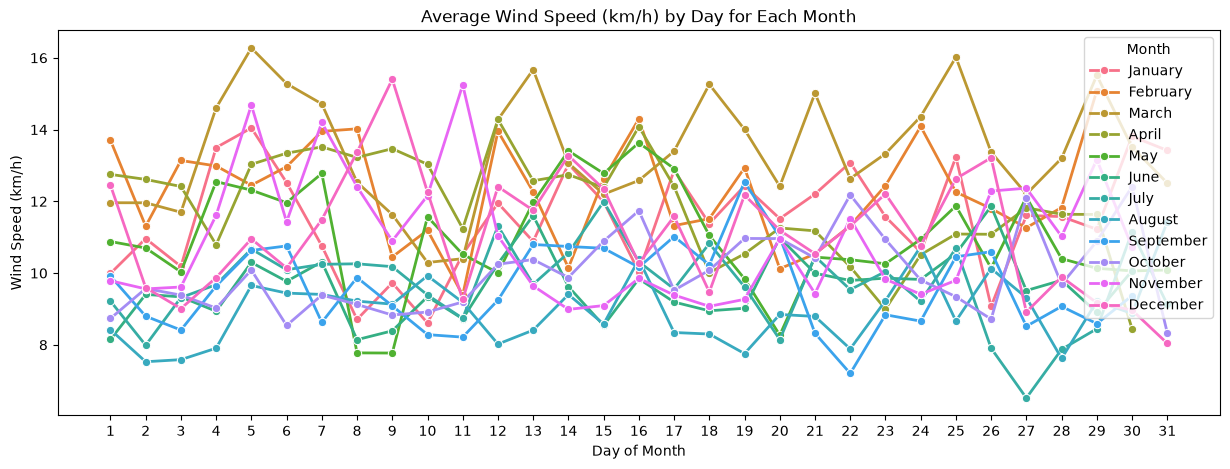

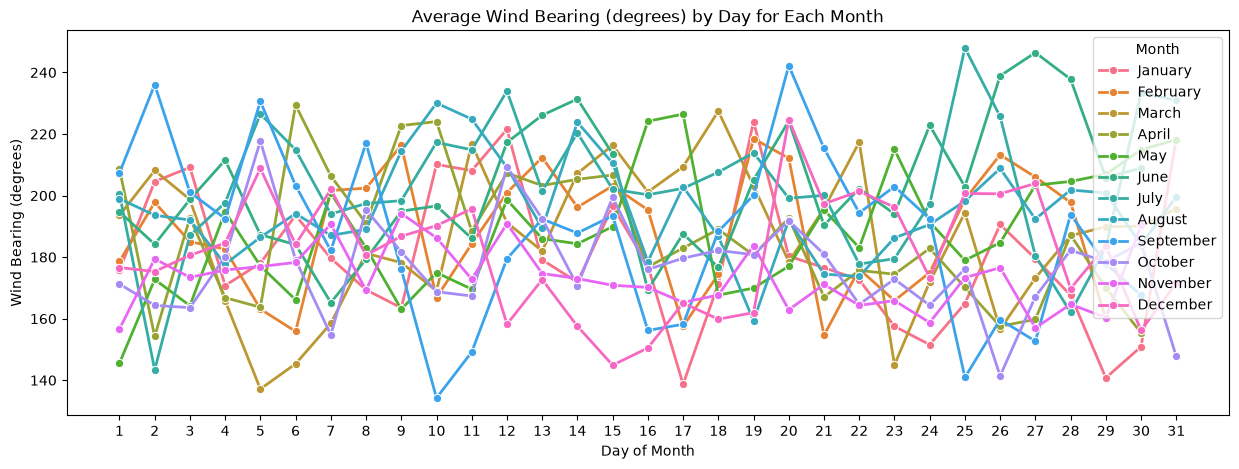

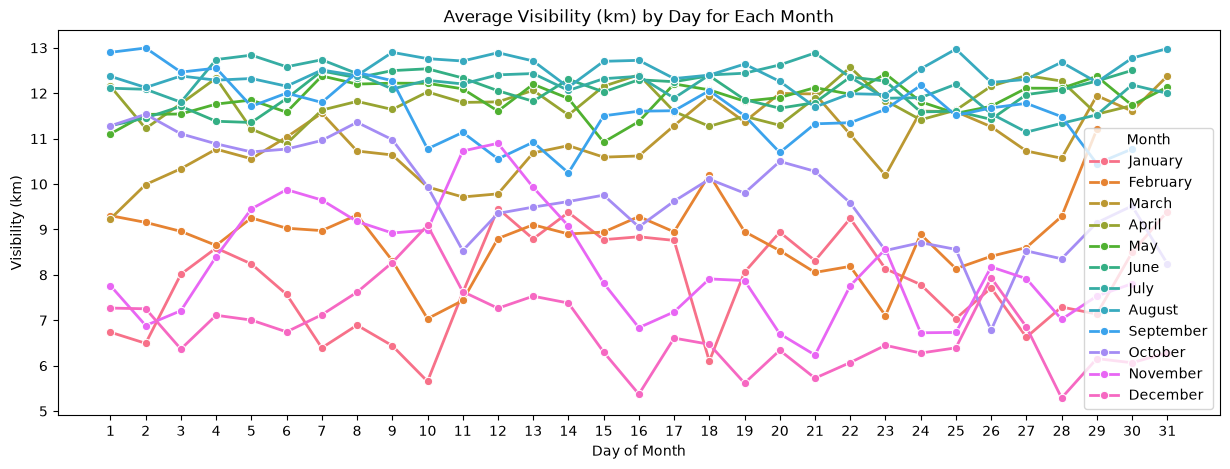

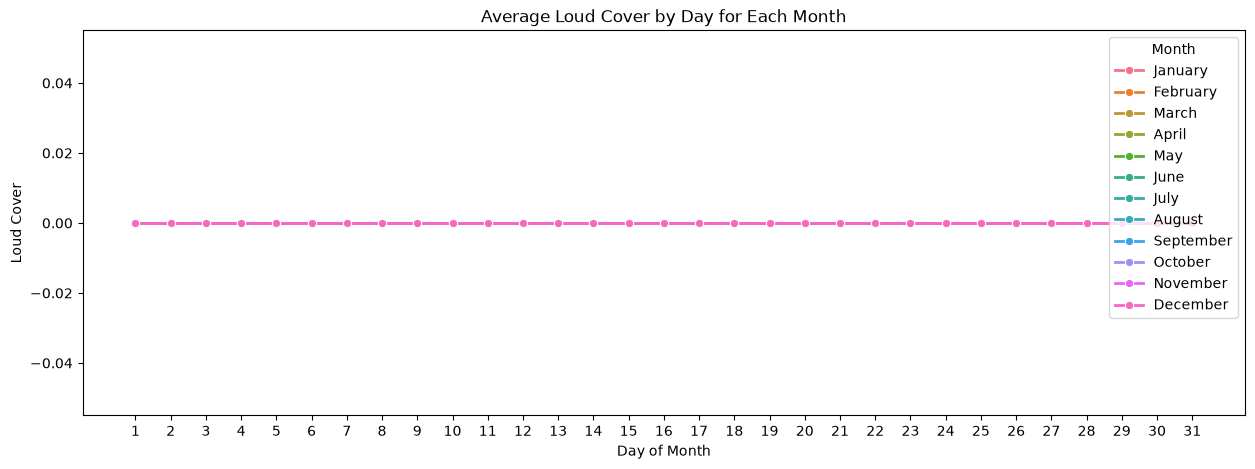

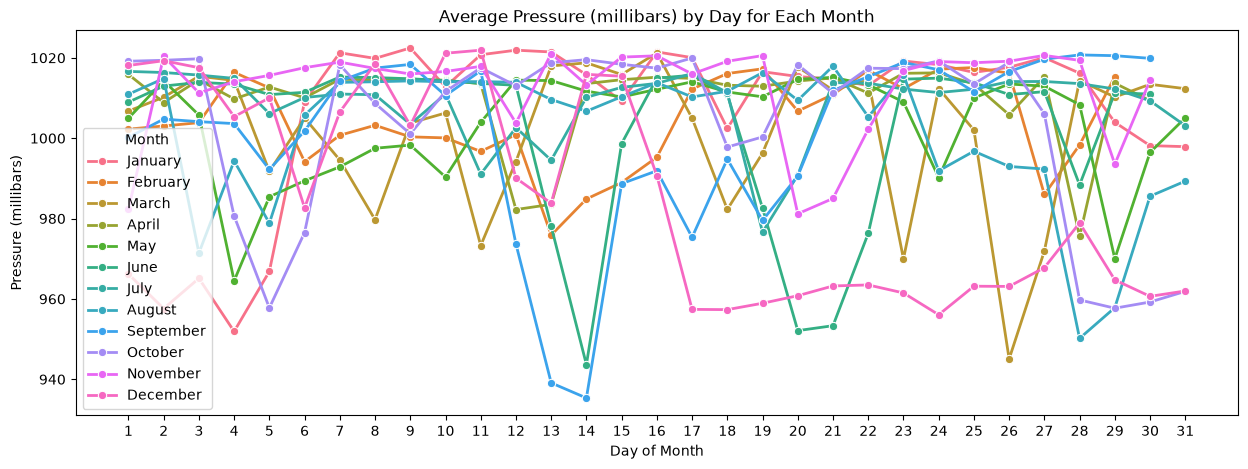

In [29]:
features = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Loud Cover',
    'Pressure (millibars)'
]

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

for feature in features:

    monthly_day = (
        df.groupby(['Month', 'Date'])[feature]
          .mean()
          .reset_index(name='Value')
    )

    monthly_day['Month'] = pd.Categorical(
        monthly_day['Month'],
        categories=month_order,
        ordered=True
    )

    monthly_day = monthly_day.sort_values(['Month', 'Date'])

    plt.figure(figsize=(15, 5))

    sns.lineplot(
        data=monthly_day,
        x='Date',
        y='Value',
        hue='Month',
        marker='o',
        linewidth=2
    )

    plt.title(f"Average {feature} by Day for Each Month")
    plt.xlabel("Day of Month")
    plt.ylabel(feature)
    plt.xticks(range(1, 32))
    plt.show()

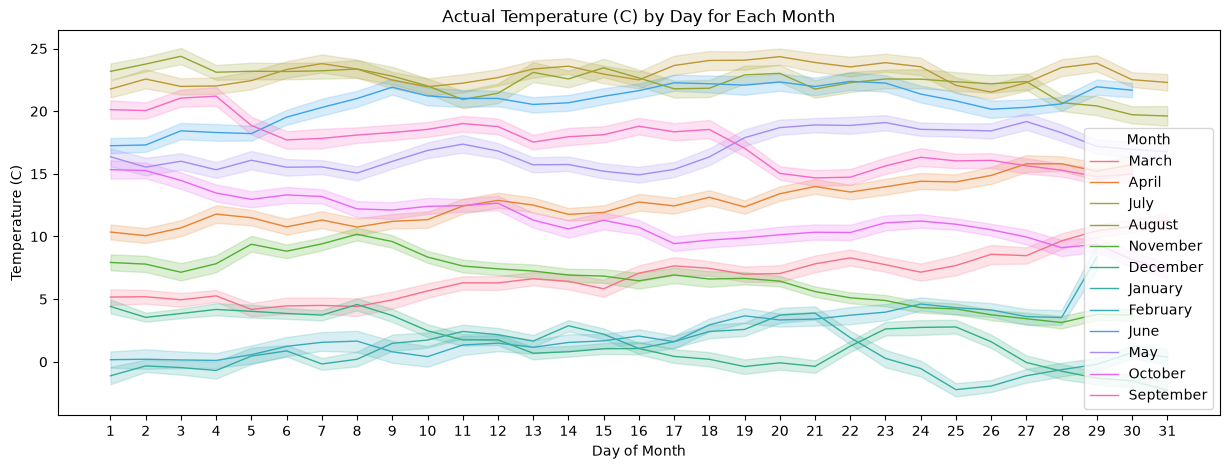

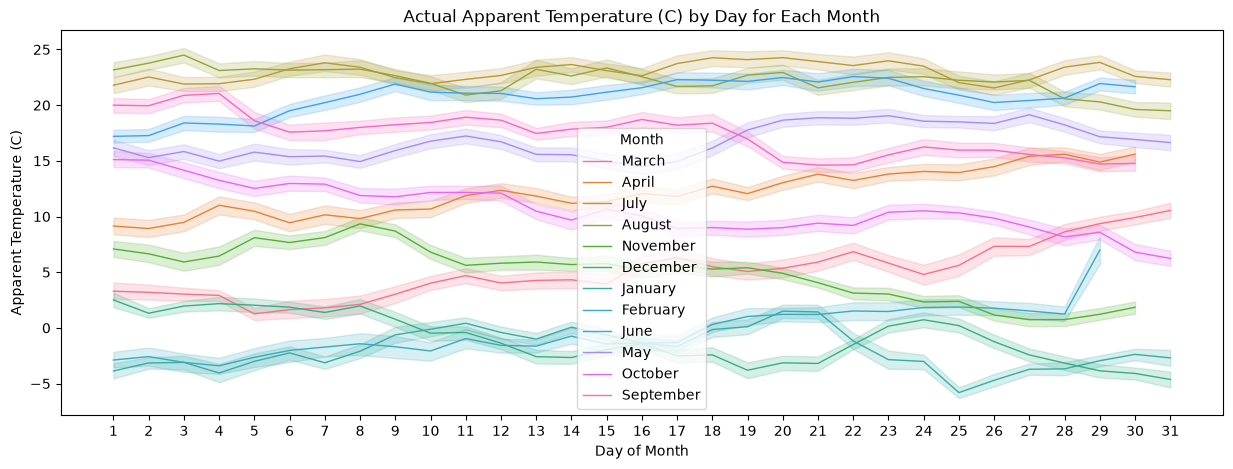

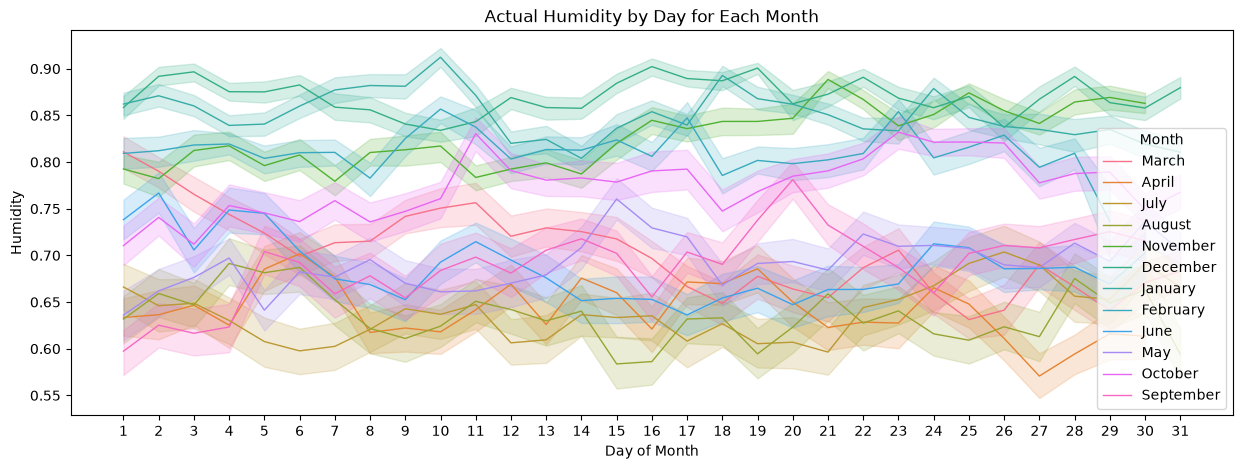

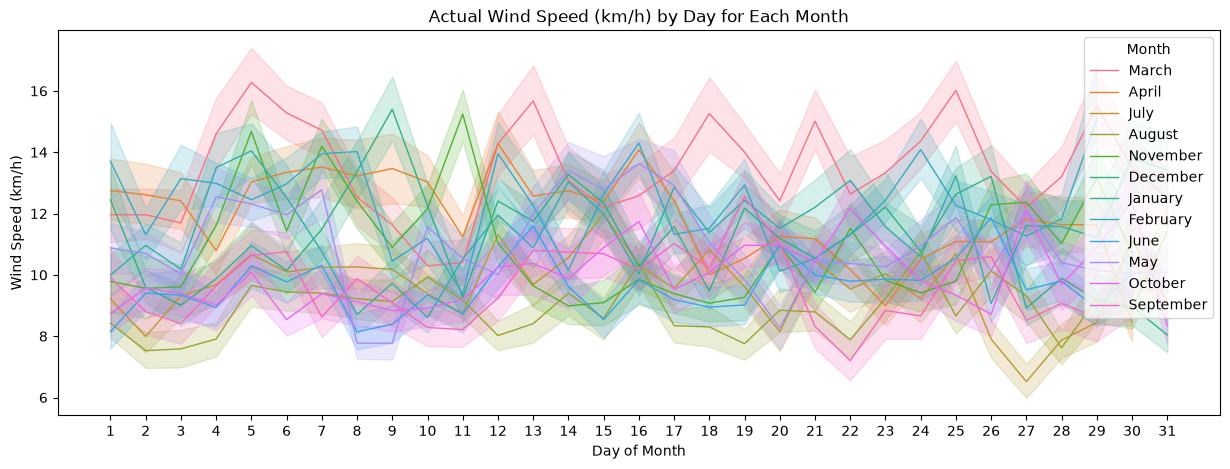

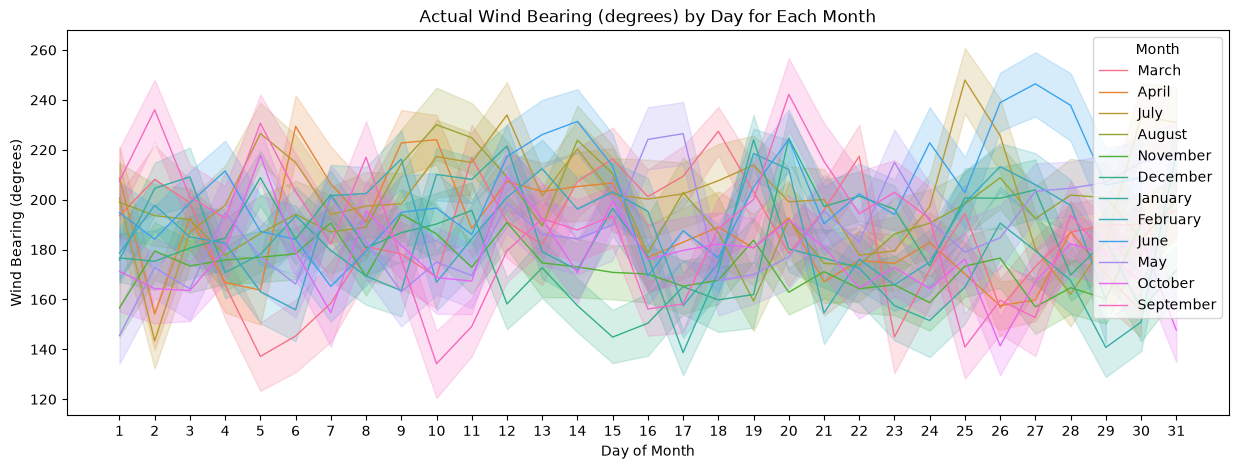

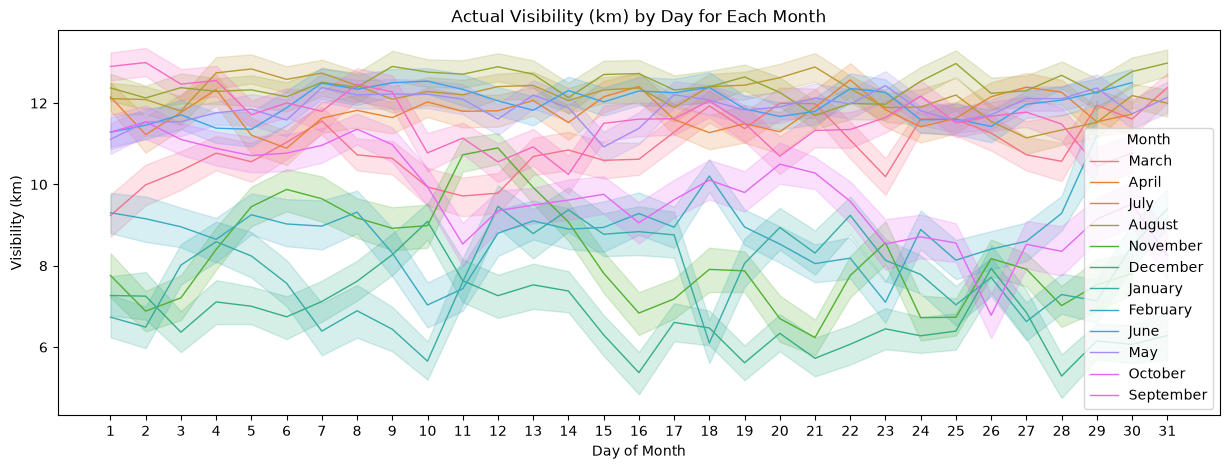

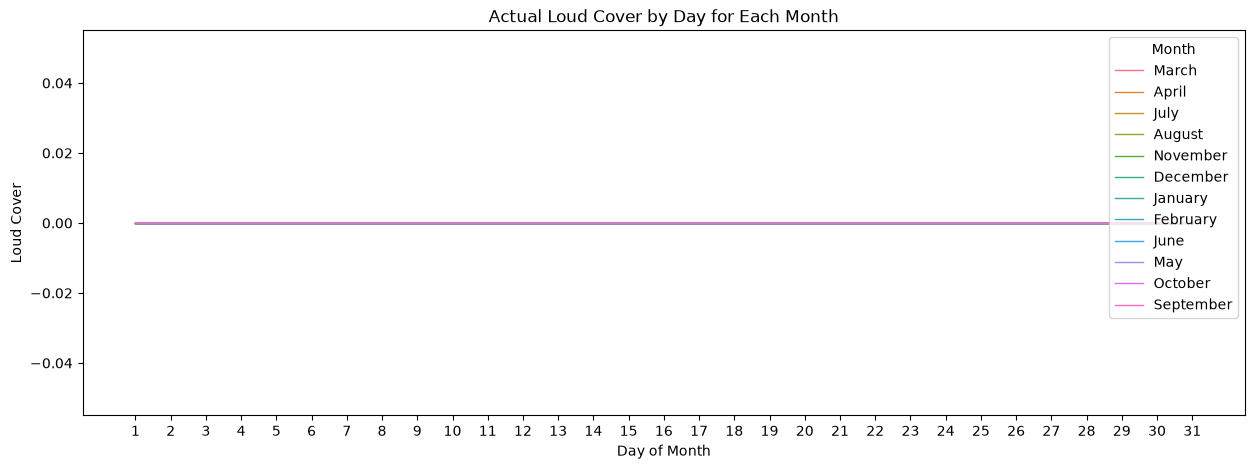

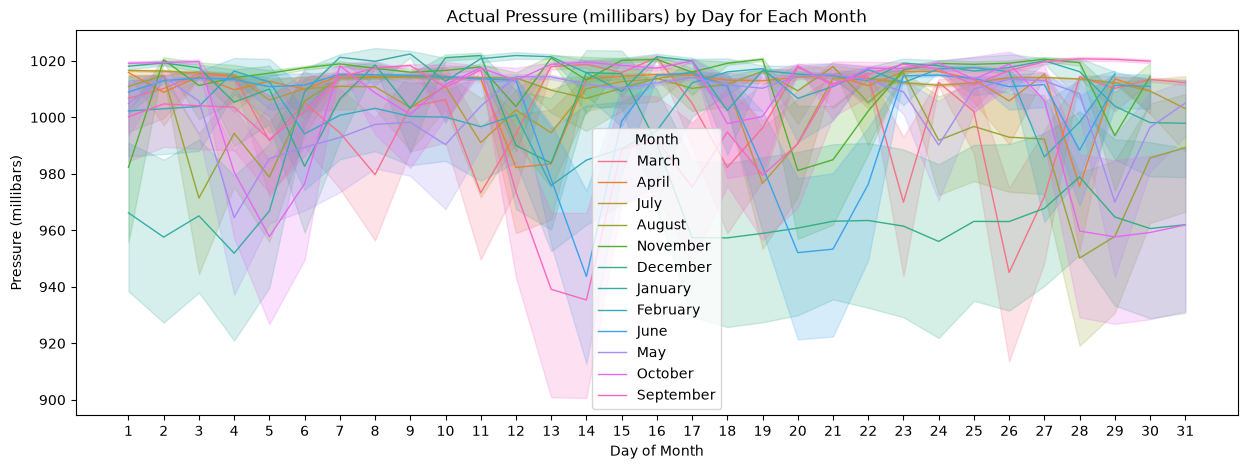

In [30]:
features = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Loud Cover',
    'Pressure (millibars)'
]

for feature in features:

    plt.figure(figsize=(15, 5))

    sns.lineplot(
        data=df,
        x='Date',
        y=feature,
        hue='Month',
        linewidth=1
    )

    plt.title(f"Actual {feature} by Day for Each Month")
    plt.xlabel("Day of Month")
    plt.ylabel(feature)
    plt.xticks(range(1, 32))
    plt.show()

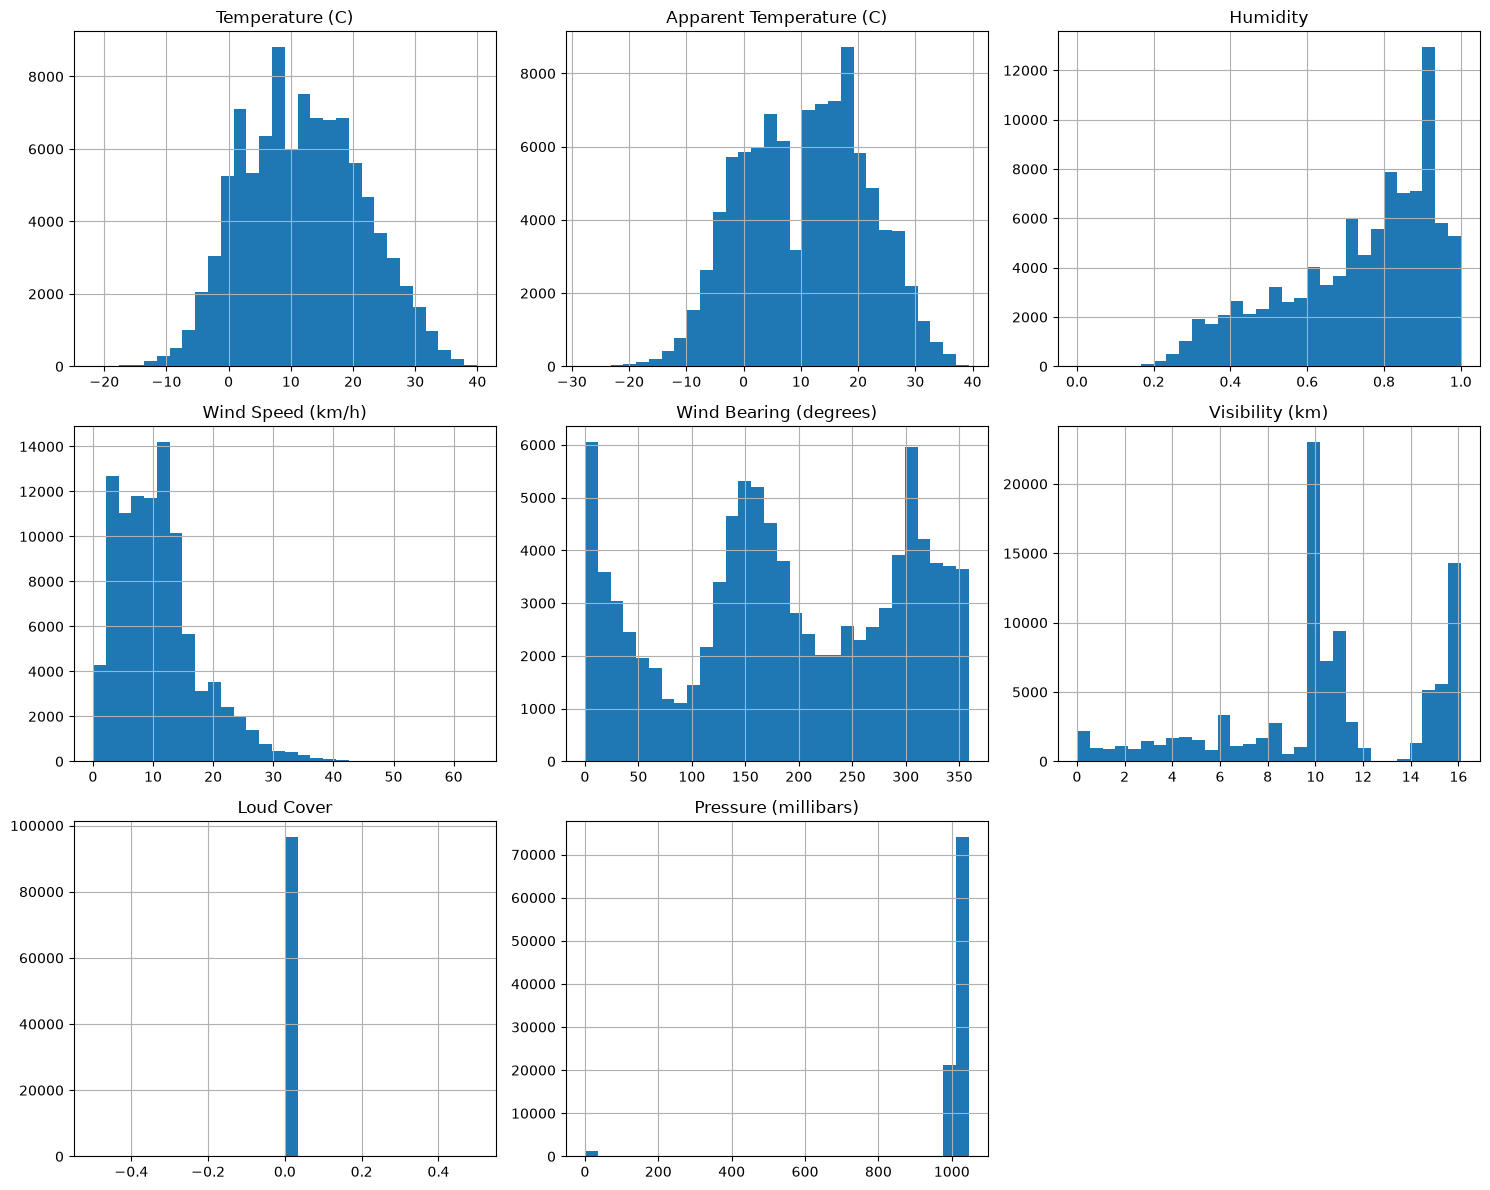

In [31]:
numerical_cols = df.select_dtypes(
    include=["float64", "int64"]
).columns

df[numerical_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

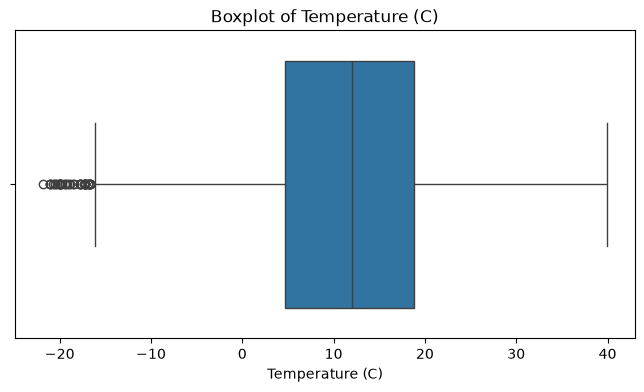

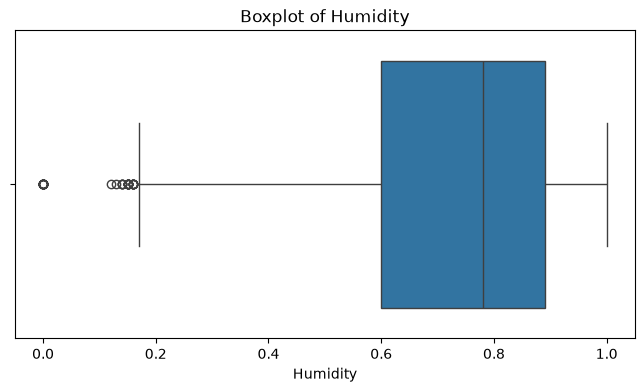

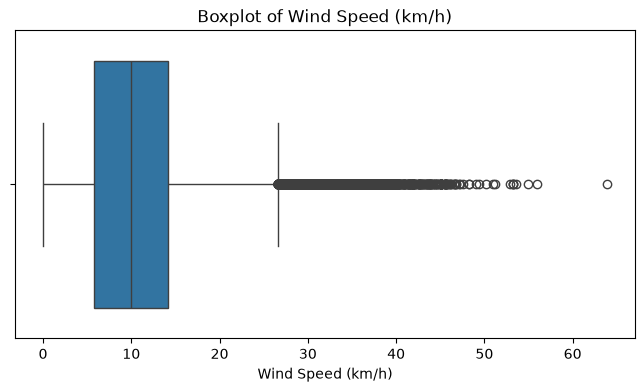

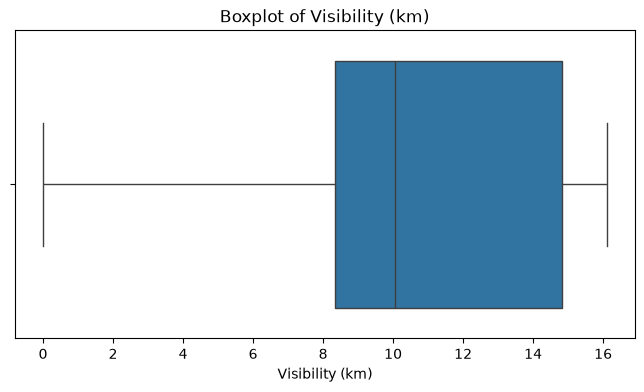

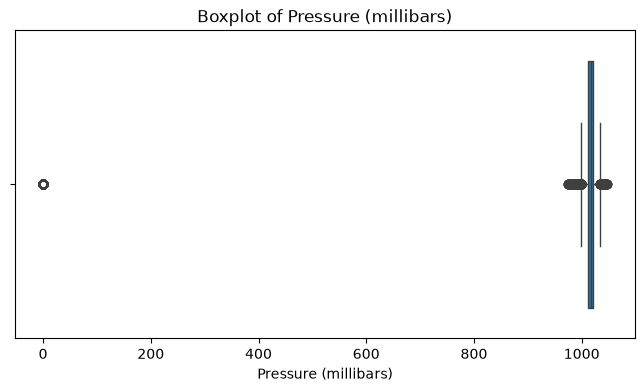

In [32]:
important_cols = [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Visibility (km)",
    "Pressure (millibars)"
]

for col in important_cols:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.show()

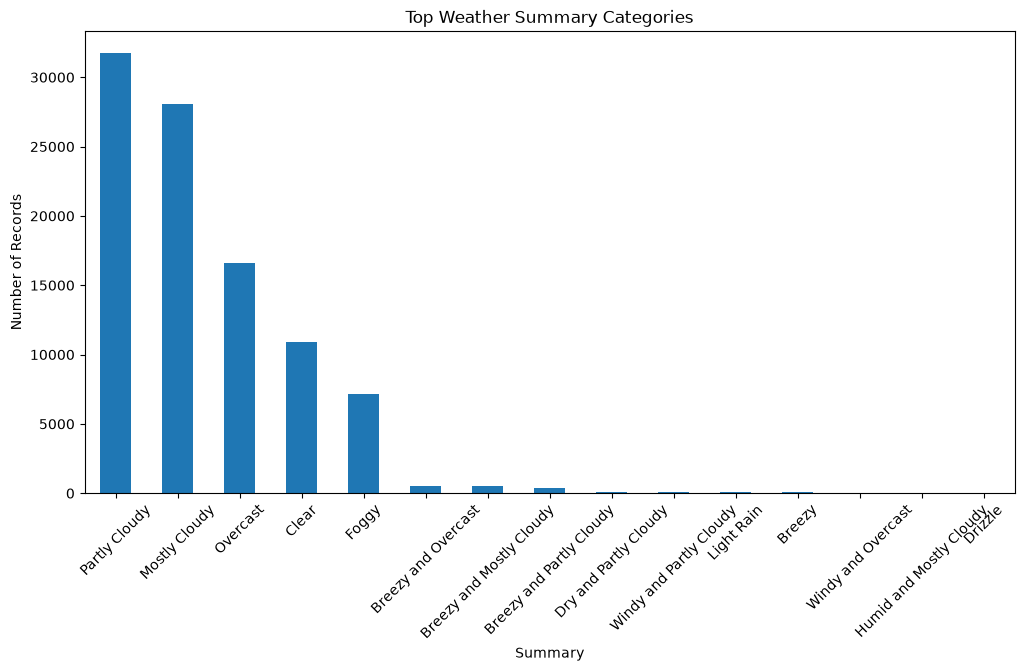

In [33]:
plt.figure(figsize=(12, 6))

df["Summary"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Weather Summary Categories")
plt.xlabel("Summary")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

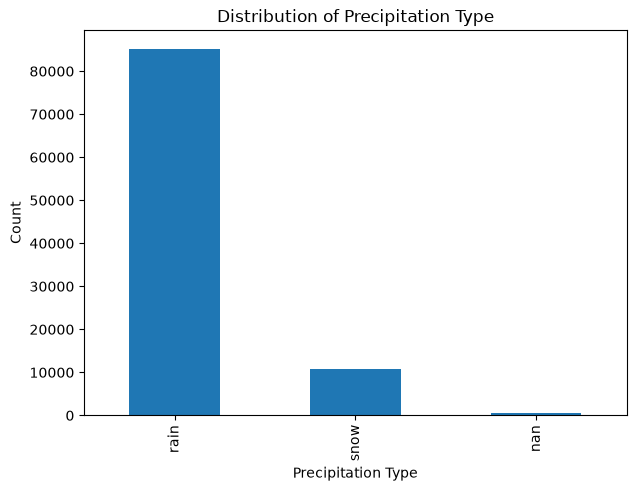

In [34]:
plt.figure(figsize=(7, 5))

df["Precip Type"].value_counts(
    dropna=False
).plot(kind="bar")

plt.title("Distribution of Precipitation Type")
plt.xlabel("Precipitation Type")
plt.ylabel("Count")
plt.show()

# Scaling & Dimensionality Reduction (PCA)
**IT Number:** IT25101195 · **Name:** Perera G.T. D · **Dataset:** `weatherHistory.csv`

## 1. Why this technique is needed
The numeric weather columns sit on very different scales — Humidity ranges roughly 0–1, Pressure sits around 1000, Wind Speed up to ~64. Any distance-based model (KNN, SVM, k-means) or PCA itself would let Pressure dominate purely because of its scale, not because it's more informative. Scaling puts every feature on equal footing first; PCA then checks whether the seven numeric weather columns can be compressed into fewer dimensions without losing much information.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../data/raw/weatherHistory.csv")
df["Precip Type"] = df["Precip Type"].fillna("none")

conditions = (
    (df["Wind Speed (km/h)"] < 20) &
    (df["Humidity"] < 0.80) &
    (df["Temperature (C)"] > 18) &
    (df["Apparent Temperature (C)"] < 32) &
    (~df["Precip Type"].isin(["rain", "snow"]))
)
df["suitability"] = np.where(conditions, "Suitable", "Not Suitable")

num_cols = ["Temperature (C)", "Apparent Temperature (C)", "Humidity",
            "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]
df[num_cols].describe().loc[["mean", "std", "min", "max"]]

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.000000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,1046.380000


## 1. Select Numerical Features

The numerical weather variables are selected for scaling and PCA. `Loud Cover` is excluded because it has zero variance in this dataset, so it cannot contribute useful information to PCA.

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Pressure (millibars)'
]

X = df[pca_features].copy()
print('Features used for Scaling and PCA:')
print(pca_features)
print('\nShape:', X.shape)

Features used for Scaling and PCA:
['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)']

Shape: (96453, 7)


## 2. Feature Scaling using StandardScaler

StandardScaler transforms each feature so that it has approximately **mean = 0** and **standard deviation = 1**. This is important before PCA because PCA is variance-based and otherwise variables with larger numerical scales could dominate the components.

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=pca_features)

print('Scaled feature means:')
print(X_scaled_df.mean().round(3))

print('\nScaled feature standard deviations:')
print(X_scaled_df.std().round(3))

Scaled feature means:
Temperature (C)            -0.0
Apparent Temperature (C)    0.0
Humidity                   -0.0
Wind Speed (km/h)          -0.0
Wind Bearing (degrees)     -0.0
Visibility (km)            -0.0
Pressure (millibars)       -0.0
dtype: float64

Scaled feature standard deviations:
Temperature (C)             1.0
Apparent Temperature (C)    1.0
Humidity                    1.0
Wind Speed (km/h)           1.0
Wind Bearing (degrees)      1.0
Visibility (km)             1.0
Pressure (millibars)        1.0
dtype: float64


## 3. PCA – Explained Variance

PCA is first fitted with all components to determine how much variance each principal component explains. The cumulative explained variance is then used to decide how many dimensions should be retained.

In [38]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (individual, cumulative) in enumerate(
    zip(explained_variance, cumulative_variance), start=1
):
    print(f'PC{i}: {individual * 100:.2f}% | Cumulative: {cumulative * 100:.2f}%')

PC1: 39.41% | Cumulative: 39.41%
PC2: 16.49% | Cumulative: 55.90%
PC3: 14.42% | Cumulative: 70.32%
PC4: 13.50% | Cumulative: 83.82%
PC5: 10.27% | Cumulative: 94.09%
PC6: 5.84% | Cumulative: 99.93%
PC7: 0.07% | Cumulative: 100.00%


In [39]:
pca2 = PCA(n_components=2, random_state=42)
pcs = pca2.fit_transform(X_scaled)
df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]

loadings = pd.DataFrame(pca2.components_.T, columns=["PC1", "PC2"], index=pca_features)
print("Feature loadings on the first 2 components:")
print(loadings.round(3))

Feature loadings on the first 2 components:
                            PC1    PC2
Temperature (C)           0.569 -0.134
Apparent Temperature (C)  0.561 -0.184
Humidity                 -0.480 -0.146
Wind Speed (km/h)         0.068  0.771
Wind Bearing (degrees)    0.032  0.512
Visibility (km)           0.355  0.119
Pressure (millibars)      0.007 -0.239


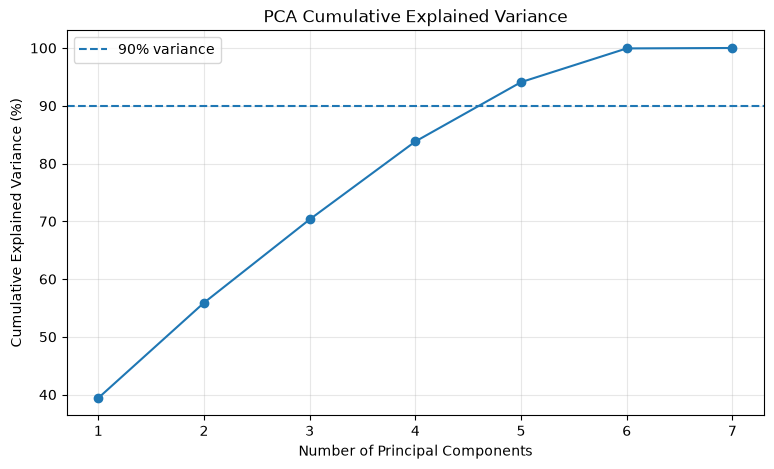

In [40]:
plt.figure(figsize=(9, 5))
components = range(1, len(explained_variance) + 1)
plt.plot(components, cumulative_variance * 100, marker='o')
plt.axhline(90, linestyle='--', label='90% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Cumulative Explained Variance')
plt.xticks(list(components))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

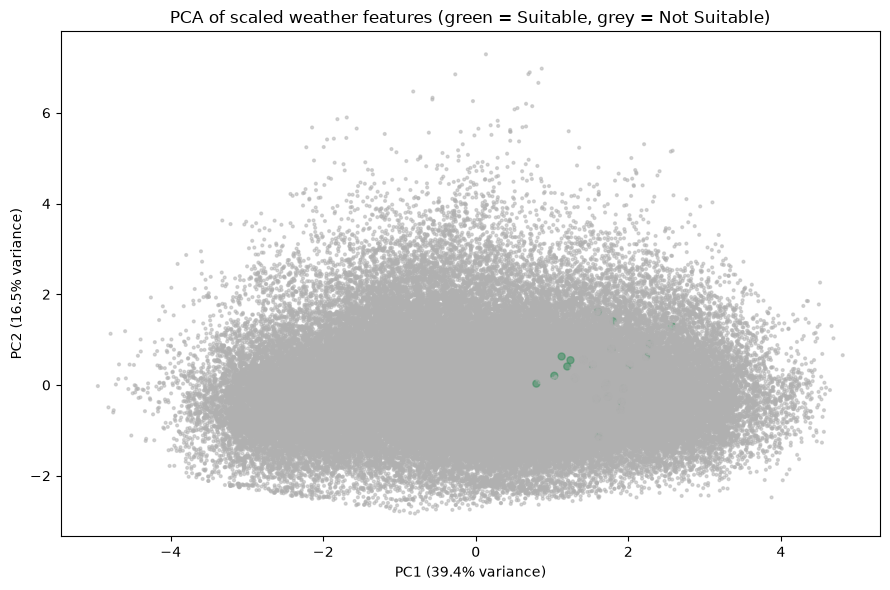

In [41]:
plt.figure(figsize=(9, 6))
colors = df["suitability"].map({"Suitable": "#2E8B57", "Not Suitable": "#B0B0B0"})
sizes = df["suitability"].map({"Suitable": 25, "Not Suitable": 4})
plt.scatter(df["PC1"], df["PC2"], c=colors, s=sizes, alpha=0.5)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of scaled weather features (green = Suitable, grey = Not Suitable)")
plt.tight_layout()
import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/member6_pca_scatter.png", dpi=110)
plt.show()

## 4. Dimensionality Reduction

Five components are retained because they provide at least 90% cumulative explained variance for this dataset. The first two components are also created separately for 2D visualization.

In [42]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print('Components required for at least 90% variance:', n_components_90)

pca_reduced = PCA(n_components=n_components_90)
X_pca = pca_reduced.fit_transform(X_scaled)

pca_columns = [f'PC{i}' for i in range(1, n_components_90 + 1)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=df.index)

print('Reduced data shape:', X_pca_df.shape)
display(X_pca_df.head())

Components required for at least 90% variance: 5
Reduced data shape: (96453, 5)


,PC1,PC2,PC3,PC4,PC5
0,-0.193205,0.781919,0.647591,0.183998,1.261343
1,-0.131097,0.861931,0.668741,0.198861,1.228804
2,-0.282776,-0.637340,0.392006,0.574167,1.392762
3,-0.186826,0.949487,0.709902,0.223026,1.242229
4,-0.138043,0.536315,0.648909,0.376349,1.318760


## 5. PCA Loadings

The loadings show how strongly the original weather features contribute to each principal component.

In [43]:
loadings = pd.DataFrame(
    pca_reduced.components_.T,
    columns=pca_columns,
    index=pca_features
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5
Temperature (C),0.569,-0.134,-0.078,0.110,-0.189
Apparent Temperature (C),0.561,-0.184,-0.079,0.149,-0.176
Humidity,-0.480,-0.146,0.029,0.207,0.188
Wind Speed (km/h),0.068,0.771,0.062,-0.474,-0.225
Wind Bearing (degrees),0.032,0.512,0.244,0.816,-0.039
Visibility (km),0.355,0.119,0.237,-0.112,0.888
Pressure (millibars),0.007,-0.239,0.931,-0.139,-0.237


## 6. Two-Component PCA Visualization

The first two principal components are used to visualize the high-dimensional weather data in two dimensions. This is mainly for visualization; the reduced dataset above retains the components needed to preserve at least 90% of the variance.

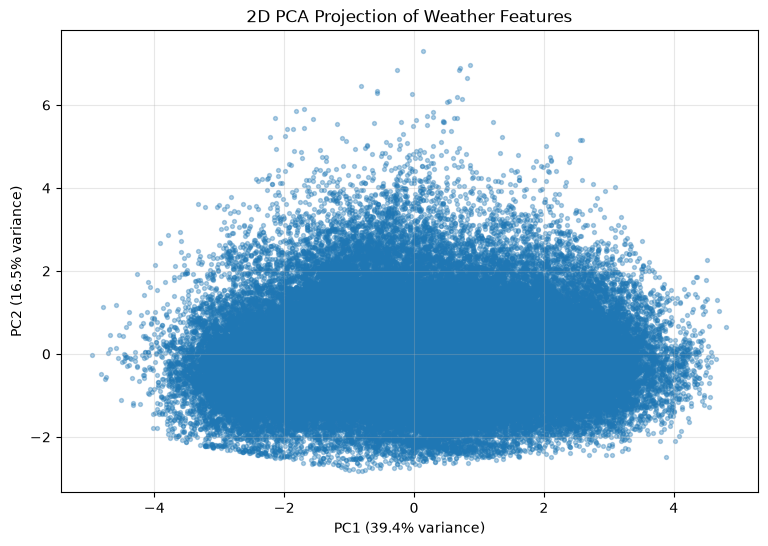

In [44]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.35, s=8)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.title('2D PCA Projection of Weather Features')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Final Scaled and PCA-Reduced Dataset

The scaled features and PCA-reduced representation are saved for later modelling/analysis.

In [45]:
final_pca_df = pd.concat(
    [
        X_scaled_df.add_prefix('Scaled_'),
        X_pca_df
    ],
    axis=1
)

output_path = '../results/outputs/scaling_dimensionality_reduction_output.csv'
final_pca_df.to_csv(output_path, index=False)

final_pca_df.to_csv("../results/outputs/member6_scaled_pca.csv", index=False)

print('Final output shape:', final_pca_df.shape)
print('Saved to:', output_path)


Final output shape: (96453, 12)
Saved to: ../results/outputs/scaling_dimensionality_reduction_output.csv


## Conclusion

StandardScaler successfully puts the selected weather variables on a common scale. PCA then reduces the dimensionality while retaining at least 90% of the variance using the selected number of principal components. The 2D PCA projection is useful for visualization, while the 90%-variance PCA representation is more appropriate when dimensionality reduction is required for further analysis or modelling.